In [28]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_parquet("../data/final_df.parquet")
# df_phage = df[df["phage_id"] != "NC_000913.3"].copy()
df = df[df["isSeqSingleton"] == False]
df

,protein_id,namespace,ribosome,embedding,phage_id,description,isPhage,representative_x,seq_cluster_id,isSeqRep,seq_cluster_size,isSeqSingleton,representative_y,struc_cluster_id,isStrucRep,struc_cluster_size,isStrucSingleton
9,NP_416080.1,cellular_component,False,"[-15.096699, -27.982311, -6.518868, -2.3490567...",NC_000913.3,toxic protein HokD,False,YP_025292.1,8671,False,3,False,YP_025292.1,5981,False,2,False
11,NP_414559.1,cellular_component,False,"[-31.014965, -33.329224, 11.923415, -4.053697,...",NC_000913.3,regulatory protein MokC,False,YP_025292.1,8671,False,3,False,NP_414559.1,229,True,1,True
13,YP_025292.1,cellular_component,False,"[-2.0192308, -27.232573, 12.711539, -30.221155...",NC_000913.3,protein HokC,False,YP_025292.1,8671,True,3,False,YP_025292.1,5981,True,2,False
68,NP_417637.1,biological_process,False,"[35.10486, 9.091604, 70.82966, 7.5949063, 72.1...",NC_000913.3,translation initiation factor IF-2beta',False,YP_010283916.1,8665,False,3,False,YP_010283915.1,5976,False,3,False
69,YP_010283916.1,biological_process,False,"[47.175697, -16.93016, 79.818085, 2.3749142, 5...",NC_000913.3,translation initiation factor IF-2beta',False,YP_010283916.1,8665,True,3,False,YP_010283915.1,5976,False,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11174,QXV80335.1,biological_process,False,"[41.742188, -129.28825, 105.71013, 18.93979, 1...",MZ501075,hypothetical protein,True,QXV77353.1,4657,False,10,False,QXV79765.1,2849,False,2,False
11175,QXV77353.1,biological_process,False,"[45.662178, -141.82974, 106.98464, 54.453396, ...",MZ501058,hypothetical protein,True,QXV77353.1,4657,True,10,False,QXV77353.1,2377,True,4,False
11176,QXV84713.1,biological_process,False,"[56.83944, -110.509155, 109.23262, 36.626076, ...",MZ501105,hypothetical protein,True,QXV77353.1,4657,False,10,False,QXV77353.1,2377,False,4,False
11189,NP_417461.1,biological_process,False,"[117.425896, -23.918413, 92.63223, 3.7473178, ...",NC_000913.3,metal phosphate:H(+) symporter PitB,False,NP_417950.1,3280,False,2,False,NP_414697.1,288,False,100,False


# TSNE

In [53]:
X = np.vstack(df["embedding"].values)

tsne = TSNE(n_components=2, random_state=42, perplexity=100, max_iter=1000)
X_tsne = tsne.fit_transform(X)

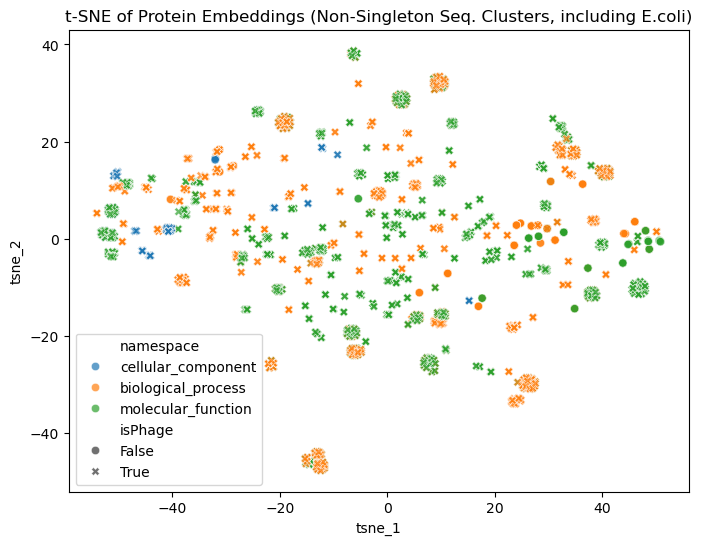

In [55]:
df["tsne_1"] = X_tsne[:, 0]
df["tsne_2"] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="tsne_1",
    y="tsne_2",
    hue="namespace",
    palette="tab10",
    alpha=0.7,
    style="isPhage",
)
plt.title("t-SNE of Protein Embeddings (Non-Singleton Seq. Clusters, including E.coli)")
# plt.legend(title="Namespace")
# plt.legend([], [], frameon=False)
plt.show()

In [5]:
import umap

/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
X = np.vstack(df["embedding"].values)

umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, metric="correlation")
X_umap = umap_model.fit_transform(X)

/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/sam_linux/miniconda3/envs/esm/lib/python3.13/site-packages/umap/spectral.

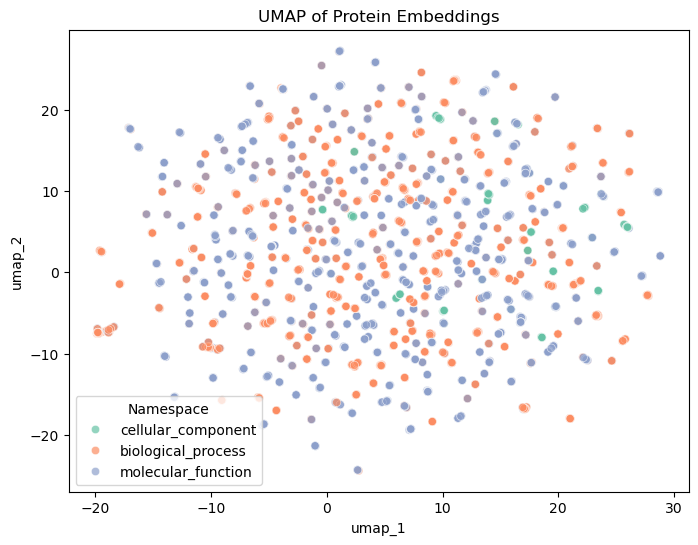

In [7]:
df["umap_1"] = X_umap[:, 0]
df["umap_2"] = X_umap[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="umap_1", y="umap_2", hue="namespace", palette="Set2", alpha=0.7
)
plt.title("UMAP of Protein Embeddings")
plt.legend(title="Namespace")
plt.show()